<a href="https://colab.research.google.com/github/NafeesSayyed/Marketing-Mix-Modelling---Data-Science-Project/blob/main/02_mmm_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mmm_dataset.csv')
df = df.dropna(subset=['sales']) #dropped the null vales in target column i.e sales

In [3]:
df.head(5)

,date,holiday,sales_promotion,competitor_spend,instagram_spend,google_ads_spend,tv_spend,youtube_spend,newspaper_spend,influencer_spend,ott_spend,sales
0,03-01-2022,0,BOGO,262550.0,54880.0,NaN,47580.0,57190.0,NaN,34610.0,NaN,1084031.0
1,10-01-2022,0,Normal,310750.0,67170.0,NaN,60140.0,64150.0,NaN,18000.0,NaN,1225796.0
2,17-01-2022,0,Flash Sale,361600.0,90520.0,NaN,52180.0,30710.0,NaN,48300.0,NaN,1445628.0
3,24-01-2022,0,Normal,293650.0,77800.0,NaN,41940.0,39610.0,NaN,49160.0,NaN,1445965.0
4,31-01-2022,0,Normal,343700.0,87050.0,NaN,29720.0,23430.0,NaN,34790.0,NaN,1370267.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 0 to 208
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              206 non-null    object 
 1   holiday           206 non-null    int64  
 2   sales_promotion   206 non-null    object 
 3   competitor_spend  197 non-null    float64
 4   instagram_spend   156 non-null    float64
 5   google_ads_spend  127 non-null    float64
 6   tv_spend          149 non-null    float64
 7   youtube_spend     141 non-null    float64
 8   newspaper_spend   143 non-null    float64
 9   influencer_spend  148 non-null    float64
 10  ott_spend         157 non-null    float64
 11  sales             206 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 20.9+ KB


In [5]:
df.isnull().sum()

,0
date,0
holiday,0
sales_promotion,0
competitor_spend,9
instagram_spend,50
google_ads_spend,79
tv_spend,57
youtube_spend,65
newspaper_spend,63
influencer_spend,58


Handeling null values

In [6]:
#Replaced 0 where channel spend was null
channels = df.columns[4:-1].tolist()
df[channels] = df[channels].fillna(0)

In [7]:
#Replaced missing competitor spend with mean value
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(df[['competitor_spend']])
df['competitor_spend'] = imputer.transform(df[['competitor_spend']])

In [8]:
df.isnull().sum()

,0
date,0
holiday,0
sales_promotion,0
competitor_spend,0
instagram_spend,0
google_ads_spend,0
tv_spend,0
youtube_spend,0
newspaper_spend,0
influencer_spend,0


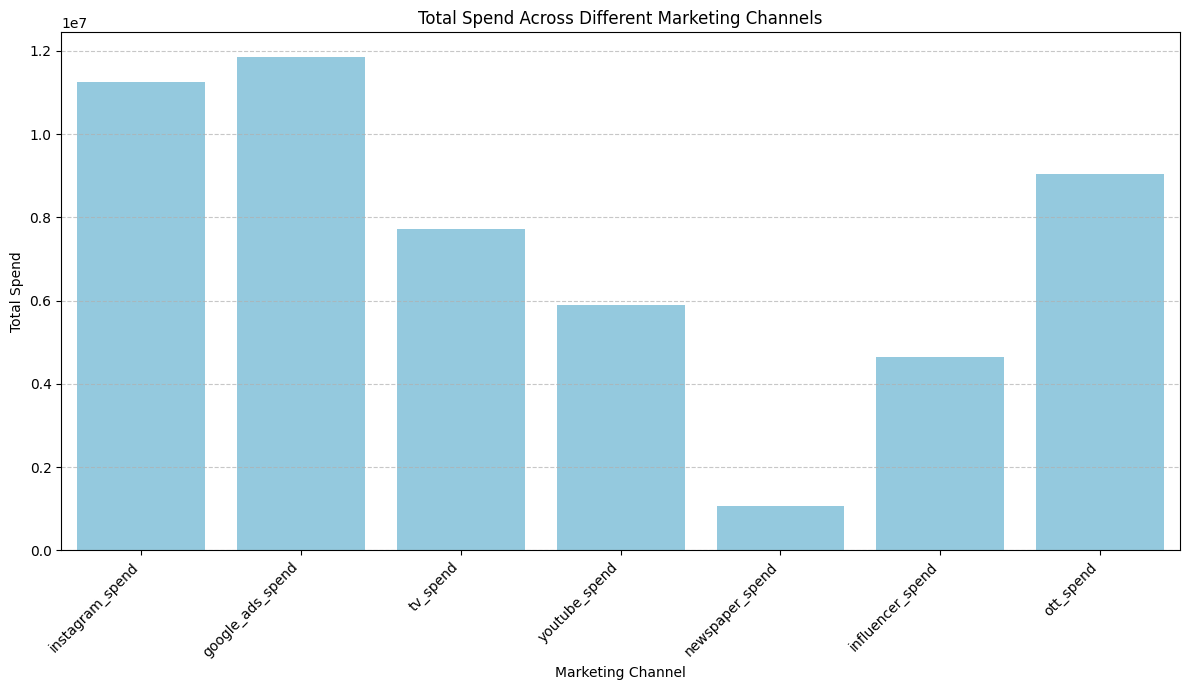

In [9]:
total_spend = df.iloc[:, 4:-1].sum(axis=0)

plt.figure(figsize=(12, 7))
sns.barplot(x=total_spend.index, y=total_spend.values, color='skyblue', legend=False)

plt.title('Total Spend Across Different Marketing Channels')
plt.xlabel('Marketing Channel')
plt.ylabel('Total Spend')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Adstock Function

In [10]:
import numpy as np
import pandas as pd

def adstock(series, decay=0.5):
    result = np.zeros(len(series))

    for t in range(len(series)):
        if t == 0:
            result[t] = series.iloc[t]
        else:
            result[t] = series.iloc[t] + decay * result[t-1]

    return pd.Series(result, index=series.index)

In [11]:
for col in channels:
    df[col] = adstock(df[col], decay = 0.5)

In [12]:
df['date'] = pd.to_datetime(df['date'], format = '%d-%m-%Y')

In [13]:
df

,date,holiday,sales_promotion,competitor_spend,instagram_spend,google_ads_spend,tv_spend,youtube_spend,newspaper_spend,influencer_spend,ott_spend,sales
0,2022-01-03,0,BOGO,262550.0,54880.000000,0.000000,47580.000000,57190.000000,0.000000,34610.000000,0.000000,1084031.0
1,2022-01-10,0,Normal,310750.0,94610.000000,0.000000,83930.000000,92745.000000,0.000000,35305.000000,0.000000,1225796.0
2,2022-01-17,0,Flash Sale,361600.0,137825.000000,0.000000,94145.000000,77082.500000,0.000000,65952.500000,0.000000,1445628.0
3,2022-01-24,0,Normal,293650.0,146712.500000,0.000000,89012.500000,78151.250000,0.000000,82136.250000,0.000000,1445965.0
4,2022-01-31,0,Normal,343700.0,160406.250000,0.000000,74226.250000,62505.625000,0.000000,75858.125000,0.000000,1370267.0
...,...,...,...,...,...,...,...,...,...,...,...,...
204,2025-12-01,0,BOGO,252250.0,128226.871343,99138.832207,75378.923862,107210.674351,7660.665170,48153.529037,115794.586103,2824619.0
205,2025-12-08,0,Coupons,344050.0,149643.435672,49569.416104,107699.461931,104545.337175,10800.332585,67986.764519,130347.293052,2747119.0
206,2025-12-15,0,Coupons,291550.0,176211.717836,24784.708052,116539.730966,78352.668588,12100.166292,64933.382259,142573.646526,2676494.0
207,2025-12-22,0,Normal,265650.0,157975.858918,12392.354026,104639.865483,92426.334294,15420.083146,68126.691130,123796.823263,2489367.0


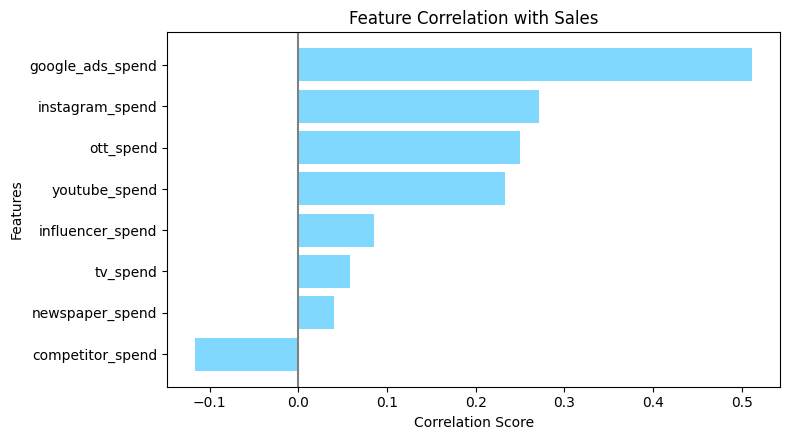

In [14]:
features = channels + ['competitor_spend']
corrs = df[features].corrwith(df['sales']).sort_values(ascending=True)
plt.figure(figsize=(8,4.5))
plt.barh(corrs.index, corrs.values, color='#80D8FF')
plt.axvline(x=0, color='grey', linestyle='-')
plt.title('Feature Correlation with Sales')
plt.xlabel('Correlation Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

Log Transformation

In [15]:
for col in channels:
    df[col] = np.log1p(df[col])**4

Spend vs Sales - Time series analysis

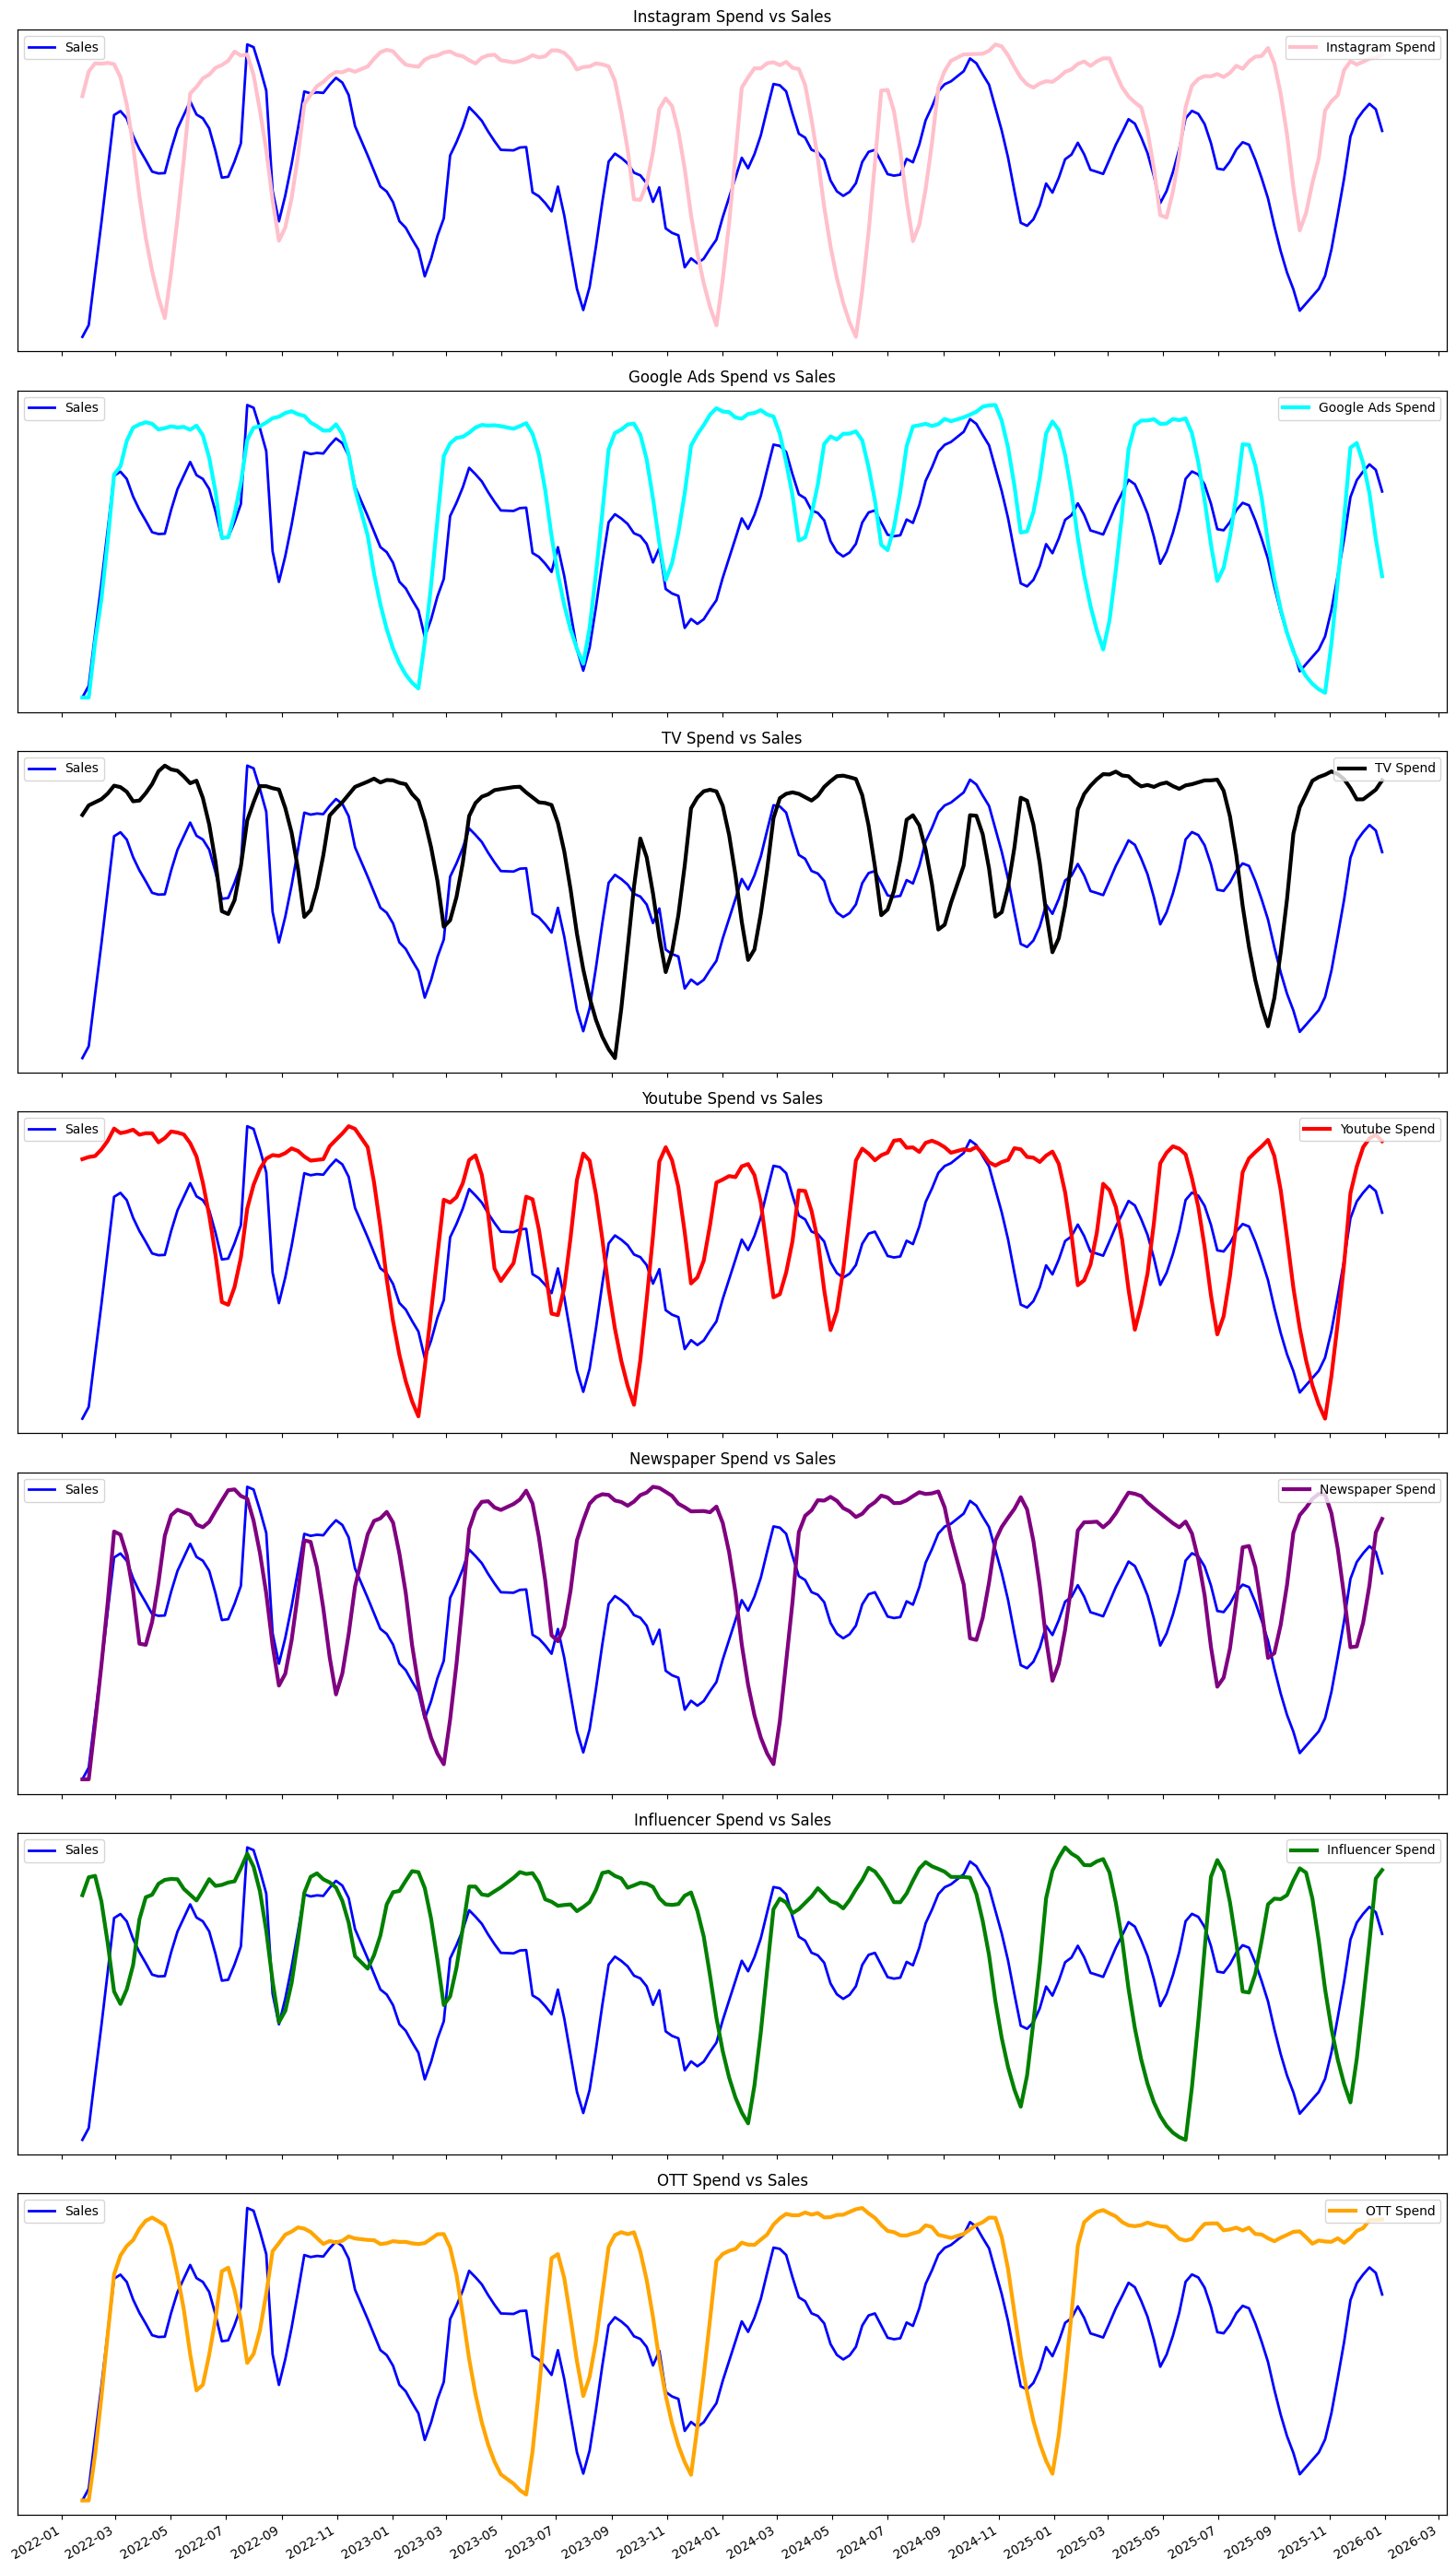

In [16]:
import matplotlib.dates as mpl_dates

fig, axes = plt.subplots(7, 1, figsize=(16,28), sharex=True)

# Instagram Spend vs Sales
ax1 = axes[0]
ax1.plot(df['date'], df['sales'].rolling(4).mean(),
         linewidth=2, label='Sales', color='blue')
ax1b = ax1.twinx()
ax1b.plot(df['date'], df['instagram_spend'].rolling(4).mean(),
          linewidth=3, label='Instagram Spend', color='pink')
ax1.set_title("Instagram Spend vs Sales")
ax1.legend(loc="upper left")
ax1b.legend(loc="upper right")

# Google Ads Spend vs Sales
ax2 = axes[1]
ax2.plot(df['date'], df['sales'].rolling(4).mean(),
         linewidth=2, label='Sales', color='blue')
ax2b = ax2.twinx()
ax2b.plot(df['date'], df['google_ads_spend'].rolling(4).mean(),
          linewidth=3, label='Google Ads Spend', color='cyan')
ax2.set_title("Google Ads Spend vs Sales")
ax2.legend(loc="upper left")
ax2b.legend(loc="upper right")

# TV Spend vs Sales
ax3 = axes[2]
ax3.plot(df['date'], df['sales'].rolling(4).mean(),
         linewidth=2, label='Sales', color='blue')
ax3b = ax3.twinx()
ax3b.plot(df['date'], df['tv_spend'].rolling(4).mean(),
          linewidth=3, label='TV Spend', color='black')
ax3.set_title("TV Spend vs Sales")
ax3.legend(loc="upper left")
ax3b.legend(loc="upper right")

# Youtube Spend vs Sales
ax4 = axes[3]
ax4.plot(df['date'], df['sales'].rolling(4).mean(),
         linewidth=2, label='Sales', color='blue')
ax4b = ax4.twinx()
ax4b.plot(df['date'], df['youtube_spend'].rolling(4).mean(),
          linewidth=3, label='Youtube Spend', color='red')
ax4.set_title("Youtube Spend vs Sales")
ax4.legend(loc="upper left")
ax4b.legend(loc="upper right")

# Newspaper Spend vs Sales
ax5 = axes[4]
ax5.plot(df['date'], df['sales'].rolling(4).mean(),
         linewidth=2, label='Sales', color='blue')
ax5b = ax5.twinx()
ax5b.plot(df['date'], df['newspaper_spend'].rolling(4).mean(),
          linewidth=3, label='Newspaper Spend', color='purple')
ax5.set_title("Newspaper Spend vs Sales")
ax5.legend(loc="upper left")
ax5b.legend(loc="upper right")

# Influencer Spend vs Sales
ax6 = axes[5]
ax6.plot(df['date'], df['sales'].rolling(4).mean(),
         linewidth=2, label='Sales', color='blue')
ax6b = ax6.twinx()
ax6b.plot(df['date'], df['influencer_spend'].rolling(4).mean(),
          linewidth=3, label='Influencer Spend', color='green')
ax6.set_title("Influencer Spend vs Sales")
ax6.legend(loc="upper left")
ax6b.legend(loc="upper right")

# OTT Spend vs Sales
ax7 = axes[6]
ax7.plot(df['date'], df['sales'].rolling(4).mean(),
         linewidth=2, label='Sales', color='blue')
ax7b = ax7.twinx()
ax7b.plot(df['date'], df['ott_spend'].rolling(4).mean(),
          linewidth=3, label='OTT Spend', color='orange')
ax7.set_title("OTT Spend vs Sales")
ax7.legend(loc="upper left")
ax7b.legend(loc="upper right")

for ax in axes:
    ax.xaxis.set_major_locator(mpl_dates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mpl_dates.DateFormatter('%Y-%m'))
    ax.set_yticks([])
    ax.set_yticklabels([])

for ax in [ax1b, ax2b, ax3b, ax4b, ax5b, ax6b, ax7b]:
    ax.set_yticks([])
    ax.set_yticklabels([])

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

Converted raw dates into periodic week-based sine and cosine features

In [17]:
df['week'] = df['date'].dt.isocalendar().week.astype(int)

In [18]:
df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)
df = df.drop(columns=['date', 'week'])
cols = df.columns.tolist()
df = df[cols[-2:] + cols[:-2]]

Saving the processed dataset

In [19]:
df.to_csv('mmm_processed_dataset.csv', index = False)